# Convolutional Neural Network Code

## TODO (might be outdated)
- Create a bespoke CNN model for this data set
- Think about cropping the image to only include the road maybe but I guess the image has to be square
- Think of how much padding should be applied to this CNN based on how important the borders of the image are, consult this article (https://medium.com/thedeephub/convolutional-neural-networks-a-comprehensive-guide-5cc0b5eae175) and think about the stride too.
- Will probably need to add padding 
- Choose a method to normalize the data you have which is helpful for YOUR data


Loading libraries in the code cell below:

In [1]:
# from tensorflow.keras import datasets, layers, models
# import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim

from PIL import Image
from sklearn.model_selection import GroupShuffleSplit
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torchvision.models import ResNet18_Weights

from pathlib import Path
import ast
import re

## Creating the New Data Manifests [Do not run]
- image-manifest.csv — 488 rows, one per CNN image.
- lap-manifest.csv — 122 rows, one per eligible lap. This will be especially useful for session-based splitting and combining CNN probabilities with delta features.

In [ ]:
# TODO: Get rid of this later since you know all these details

possible_data_directories = [
    Path("../Data"),
    Path("Data"),
]

data_dir = next(
    (
        candidate.resolve()
        for candidate in possible_data_directories
        if candidate.exists()
    ),
    None,
)

if data_dir is None:
    raise FileNotFoundError(
        "Could not find the Data directory.\n"
        f"Current working directory: {Path.cwd()}"
    )

project_root = data_dir.parent
cnn_dir = data_dir / "cnn-classes"
association_csv = (
    data_dir
    / "collated-data"
    / "lap-image-association.csv"
)

manifest_dir = data_dir / "manifests"
manifest_dir.mkdir(exist_ok=True)

print("Project root:", project_root)
print("CNN directory:", cnn_dir)
print("Association CSV:", association_csv)
print("Manifest directory:", manifest_dir)

if not cnn_dir.exists():
    raise FileNotFoundError(
        f"CNN directory was not found:\n{cnn_dir}"
    )

if not association_csv.exists():
    raise FileNotFoundError(
        f"Association CSV was not found:\n{association_csv}"
    )

Project root: C:\Users\admin\Desktop\Summer Projects\F1\F1-Optimized-Cornering-Project
CNN directory: C:\Users\admin\Desktop\Summer Projects\F1\F1-Optimized-Cornering-Project\Data\cnn-classes
Association CSV: C:\Users\admin\Desktop\Summer Projects\F1\F1-Optimized-Cornering-Project\Data\collated-data\lap-image-association.csv
Manifest directory: C:\Users\admin\Desktop\Summer Projects\F1\F1-Optimized-Cornering-Project\Data\manifests


In [13]:
def parse_list_cell(value):
    """
    Convert a string representation of a Python list into a list.
    """
    if isinstance(value, list):
        return value

    if pd.isna(value):
        return []

    value = str(value).strip()

    if not value:
        return []

    parsed_value = ast.literal_eval(value)

    if not isinstance(parsed_value, list):
        raise ValueError(
            f"Expected a list but received: {parsed_value!r}"
        )

    return parsed_value


association_df = pd.read_csv(association_csv)

list_columns = [
    "related_b_hits",
    "related_t_hits",
    "brake_throttle_deltas",
]

for column in list_columns:
    association_df[column] = (
        association_df[column].apply(parse_list_cell)
    )

association_df["brake_count"] = (
    association_df["related_b_hits"].apply(len)
)

association_df["throttle_count"] = (
    association_df["related_t_hits"].apply(len)
)

eligible_laps = association_df[
    (association_df["incident"] == "none")
    & (association_df["s1_time"] < 30000)
    & (association_df["brake_count"] == 2)
    & (association_df["throttle_count"] == 2)
].copy()

if eligible_laps["lap_num"].duplicated().any():
    duplicated_laps = eligible_laps.loc[
        eligible_laps["lap_num"].duplicated(keep=False),
        "lap_num",
    ].tolist()

    raise ValueError(
        "Duplicate global lap numbers were found: "
        f"{duplicated_laps}"
    )

eligible_laps["lap_num"] = (
    eligible_laps["lap_num"].astype(int)
)

print("Eligible laps:", len(eligible_laps))

Eligible laps: 122


In [14]:
q1 = np.quantile(
    eligible_laps["s1_time"],
    0.25,
)

q3 = np.quantile(
    eligible_laps["s1_time"],
    0.75,
)


def assign_class_name(sector_time_ms):
    if sector_time_ms <= q1:
        return "optimal_laps"

    if sector_time_ms < q3:
        return "standard_laps"

    return "sub_standard_laps"


eligible_laps["expected_class"] = (
    eligible_laps["s1_time"].apply(assign_class_name)
)

class_to_index = {
    "optimal_laps": 0,
    "standard_laps": 1,
    "sub_standard_laps": 2,
}

eligible_laps["class_index"] = (
    eligible_laps["expected_class"].map(class_to_index)
)

print("Q1:", q1)
print("Q3:", q3)

display(
    eligible_laps["expected_class"]
    .value_counts()
    .rename("lap_count")
    .to_frame()
)

Q1: 28143.5
Q3: 28643.0


,lap_count
expected_class,
standard_laps,60
sub_standard_laps,31
optimal_laps,31


In [15]:
CNN_FILENAME_PATTERN = re.compile(
    r"^lap_(\d+)_(brake|throttle)_(\d+)\.png$",
    flags=re.IGNORECASE,
)

SESSION_PATTERN = re.compile(
    r"session-(\d+)",
    flags=re.IGNORECASE,
)

LOCAL_LAP_PATTERN = re.compile(
    r"Lap_(\d+)_",
    flags=re.IGNORECASE,
)

RAW_HIT_PATTERN = re.compile(
    r"hit_(\d+)",
    flags=re.IGNORECASE,
)


def extract_required_number(pattern, text, description):
    match = pattern.search(str(text))

    if match is None:
        raise ValueError(
            f"Could not extract {description} from:\n{text}"
        )

    return int(match.group(1))


def extract_session_number(raw_path):
    return extract_required_number(
        SESSION_PATTERN,
        raw_path,
        "session number",
    )


def extract_local_lap_number(raw_path):
    return extract_required_number(
        LOCAL_LAP_PATTERN,
        Path(raw_path).name,
        "session-local lap number",
    )


def extract_raw_hit_number(raw_path):
    return extract_required_number(
        RAW_HIT_PATTERN,
        Path(raw_path).name,
        "hit number",
    )


def find_raw_image_path(raw_paths, hit_number):
    """
    Find the raw image associated with a particular brake/throttle hit.
    """
    matches = [
        raw_path
        for raw_path in raw_paths
        if extract_raw_hit_number(raw_path) == hit_number
    ]

    if len(matches) != 1:
        raise ValueError(
            f"Expected exactly one raw path for hit {hit_number}, "
            f"but found {len(matches)}:\n{raw_paths}"
        )

    return matches[0]


def resolve_raw_image_path(raw_path):
    """
    Convert a raw CSV image reference into its actual path inside Data.
    """
    session_number = extract_session_number(raw_path)

    path_text = str(raw_path).replace("\\", "/")

    if "/brake/" in path_text.lower():
        signal_type = "brake"
    elif "/throttle/" in path_text.lower():
        signal_type = "throttle"
    else:
        raise ValueError(
            f"Could not identify signal type from:\n{raw_path}"
        )

    return (
        data_dir
        / "image-data"
        / f"session-{session_number}"
        / signal_type
        / Path(raw_path).name
    )

In [16]:
eligible_by_global_lap = (
    eligible_laps
    .set_index("lap_num", verify_integrity=True)
)

image_records = []

for class_directory in sorted(cnn_dir.iterdir()):
    if not class_directory.is_dir():
        continue

    current_class = class_directory.name

    if current_class not in class_to_index:
        print(
            f"Skipping unrecognised directory: "
            f"{class_directory}"
        )
        continue

    for cnn_image_path in sorted(
        class_directory.glob("*.png")
    ):
        filename_match = CNN_FILENAME_PATTERN.match(
            cnn_image_path.name
        )

        if filename_match is None:
            raise ValueError(
                "CNN filename does not match the expected format:\n"
                f"{cnn_image_path.name}"
            )

        global_lap_num = int(filename_match.group(1))
        signal_type = filename_match.group(2).lower()
        hit_number = int(filename_match.group(3))

        if global_lap_num not in eligible_by_global_lap.index:
            raise KeyError(
                f"Global lap {global_lap_num} from "
                f"{cnn_image_path.name} is not present in the "
                "eligible association data."
            )

        lap_row = eligible_by_global_lap.loc[
            global_lap_num
        ]

        expected_class = lap_row["expected_class"]

        if current_class != expected_class:
            raise ValueError(
                "Class mismatch detected:\n"
                f"Image: {cnn_image_path.name}\n"
                f"Current folder: {current_class}\n"
                f"Expected folder: {expected_class}"
            )

        if signal_type == "brake":
            raw_paths = lap_row["related_b_hits"]
        else:
            raw_paths = lap_row["related_t_hits"]

        raw_csv_path = find_raw_image_path(
            raw_paths,
            hit_number,
        )

        session_number = extract_session_number(
            raw_csv_path
        )

        local_lap_num = extract_local_lap_number(
            raw_csv_path
        )

        resolved_raw_path = resolve_raw_image_path(
            raw_csv_path
        )

        # Map each recorded delta to its brake/throttle hit pair.
        delta_by_pair = {
            (
                int(delta_entry[1]),
                int(delta_entry[2]),
            ): float(delta_entry[0])
            for delta_entry in lap_row[
                "brake_throttle_deltas"
            ]
        }

        delta_1 = delta_by_pair.get(
            (1, 1),
            np.nan,
        )

        delta_2 = delta_by_pair.get(
            (2, 2),
            np.nan,
        )

        # Both the corresponding brake and throttle image receive
        # the delta associated with their hit number.
        associated_delta = delta_by_pair.get(
            (hit_number, hit_number),
            np.nan,
        )

        image_records.append({
            "image_id": cnn_image_path.stem,
            "cnn_image_path": str(
                cnn_image_path.resolve()
            ),
            "cnn_repo_relative_path": (
                cnn_image_path.resolve()
                .relative_to(project_root.resolve())
                .as_posix()
            ),
            "class_name": current_class,
            "class_index": class_to_index[current_class],
            "global_lap_num": global_lap_num,
            "session": session_number,
            "session_lap_num": local_lap_num,
            "signal_type": signal_type,
            "hit_number": hit_number,
            "raw_csv_path": raw_csv_path,
            "raw_image_path": str(
                resolved_raw_path.resolve()
            ),
            "raw_repo_relative_path": (
                resolved_raw_path.resolve()
                .relative_to(project_root.resolve())
                .as_posix()
            ),
            "raw_image_exists": (
                resolved_raw_path.exists()
            ),
            "s1_time_ms": int(lap_row["s1_time"]),
            "s1_time_seconds": (
                float(lap_row["s1_time"]) / 1000
            ),
            "incident": lap_row["incident"],
            "delta_1_seconds": delta_1,
            "delta_2_seconds": delta_2,
            "associated_delta_seconds": (
                associated_delta
            ),
            "has_delta_data": bool(delta_by_pair),
        })


image_manifest = pd.DataFrame(image_records)

signal_order = {
    "brake": 0,
    "throttle": 1,
}

image_manifest["_signal_order"] = (
    image_manifest["signal_type"].map(signal_order)
)

image_manifest = (
    image_manifest
    .sort_values([
        "global_lap_num",
        "_signal_order",
        "hit_number",
    ])
    .drop(columns="_signal_order")
    .reset_index(drop=True)
)

display(image_manifest.head(12))

,image_id,cnn_image_path,cnn_repo_relative_path,class_name,class_index,global_lap_num,session,session_lap_num,signal_type,hit_number,...,raw_image_path,raw_repo_relative_path,raw_image_exists,s1_time_ms,s1_time_seconds,incident,delta_1_seconds,delta_2_seconds,associated_delta_seconds,has_delta_data
0,lap_0003_brake_01,C:\Users\admin\Desktop\Summer Projects\F1\F1-O...,Data/cnn-classes/sub_standard_laps/lap_0003_br...,sub_standard_laps,2,3,1,3,brake,1,...,C:\Users\admin\Desktop\Summer Projects\F1\F1-O...,Data/image-data/session-1/brake/Lap_3_Brake hi...,True,28935,28.935,none,NaN,NaN,NaN,False
1,lap_0003_brake_02,C:\Users\admin\Desktop\Summer Projects\F1\F1-O...,Data/cnn-classes/sub_standard_laps/lap_0003_br...,sub_standard_laps,2,3,1,3,brake,2,...,C:\Users\admin\Desktop\Summer Projects\F1\F1-O...,Data/image-data/session-1/brake/Lap_3_Brake hi...,True,28935,28.935,none,NaN,NaN,NaN,False
2,lap_0003_throttle_01,C:\Users\admin\Desktop\Summer Projects\F1\F1-O...,Data/cnn-classes/sub_standard_laps/lap_0003_th...,sub_standard_laps,2,3,1,3,throttle,1,...,C:\Users\admin\Desktop\Summer Projects\F1\F1-O...,Data/image-data/session-1/throttle/Lap_3_Throt...,True,28935,28.935,none,NaN,NaN,NaN,False
3,lap_0003_throttle_02,C:\Users\admin\Desktop\Summer Projects\F1\F1-O...,Data/cnn-classes/sub_standard_laps/lap_0003_th...,sub_standard_laps,2,3,1,3,throttle,2,...,C:\Users\admin\Desktop\Summer Projects\F1\F1-O...,Data/image-data/session-1/throttle/Lap_3_Throt...,True,28935,28.935,none,NaN,NaN,NaN,False
4,lap_0004_brake_01,C:\Users\admin\Desktop\Summer Projects\F1\F1-O...,Data/cnn-classes/sub_standard_laps/lap_0004_br...,sub_standard_laps,2,4,1,4,brake,1,...,C:\Users\admin\Desktop\Summer Projects\F1\F1-O...,Data/image-data/session-1/brake/Lap_4_Brake hi...,True,29188,29.188,none,NaN,NaN,NaN,False
5,lap_0004_brake_02,C:\Users\admin\Desktop\Summer Projects\F1\F1-O...,Data/cnn-classes/sub_standard_laps/lap_0004_br...,sub_standard_laps,2,4,1,4,brake,2,...,C:\Users\admin\Desktop\Summer Projects\F1\F1-O...,Data/image-data/session-1/brake/Lap_4_Brake hi...,True,29188,29.188,none,NaN,NaN,NaN,False
6,lap_0004_throttle_01,C:\Users\admin\Desktop\Summer Projects\F1\F1-O...,Data/cnn-classes/sub_standard_laps/lap_0004_th...,sub_standard_laps,2,4,1,4,throttle,1,...,C:\Users\admin\Desktop\Summer Projects\F1\F1-O...,Data/image-data/session-1/throttle/Lap_4_Throt...,True,29188,29.188,none,NaN,NaN,NaN,False
7,lap_0004_throttle_02,C:\Users\admin\Desktop\Summer Projects\F1\F1-O...,Data/cnn-classes/sub_standard_laps/lap_0004_th...,sub_standard_laps,2,4,1,4,throttle,2,...,C:\Users\admin\Desktop\Summer Projects\F1\F1-O...,Data/image-data/session-1/throttle/Lap_4_Throt...,True,29188,29.188,none,NaN,NaN,NaN,False
8,lap_0005_brake_01,C:\Users\admin\Desktop\Summer Projects\F1\F1-O...,Data/cnn-classes/standard_laps/lap_0005_brake_...,standard_laps,1,5,1,5,brake,1,...,C:\Users\admin\Desktop\Summer Projects\F1\F1-O...,Data/image-data/session-1/brake/Lap_5_Brake hi...,True,28478,28.478,none,NaN,NaN,NaN,False
9,lap_0005_brake_02,C:\Users\admin\Desktop\Summer Projects\F1\F1-O...,Data/cnn-classes/standard_laps/lap_0005_brake_...,standard_laps,1,5,1,5,brake,2,...,C:\Users\admin\Desktop\Summer Projects\F1\F1-O...,Data/image-data/session-1/brake/Lap_5_Brake hi...,True,28478,28.478,none,NaN,NaN,NaN,False


In [17]:
assert len(image_manifest) == 488, (
    f"Expected 488 image rows, found "
    f"{len(image_manifest)}."
)

assert image_manifest["image_id"].is_unique, (
    "Duplicate image IDs were found."
)

assert image_manifest["cnn_image_path"].is_unique, (
    "Duplicate CNN image paths were found."
)

assert (
    image_manifest["global_lap_num"].nunique()
    == 122
), (
    "Expected 122 unique eligible laps."
)

images_per_lap = (
    image_manifest
    .groupby("global_lap_num")
    .size()
)

assert images_per_lap.eq(4).all(), (
    "At least one lap does not have exactly four "
    "CNN images."
)

signals_per_lap = (
    image_manifest
    .groupby(
        ["global_lap_num", "signal_type"]
    )
    .size()
    .unstack(fill_value=0)
)

assert signals_per_lap["brake"].eq(2).all()
assert signals_per_lap["throttle"].eq(2).all()

assert image_manifest[
    "raw_image_exists"
].all(), (
    "At least one mapped raw image could not be found."
)

print("Image manifest validation passed.")
print("Rows:", len(image_manifest))
print(
    "Unique laps:",
    image_manifest["global_lap_num"].nunique(),
)
print(
    "Unique sessions:",
    image_manifest["session"].nunique(),
)
print(
    "Rows with delta data:",
    image_manifest["has_delta_data"].sum(),
)

Image manifest validation passed.
Rows: 488
Unique laps: 122
Unique sessions: 19
Rows with delta data: 376


### Save the image manifest

In [18]:
image_manifest_path = (
    manifest_dir / "image-manifest.csv"
)

image_manifest.to_csv(
    image_manifest_path,
    index=False,
)

print(
    "Saved image manifest to:",
    image_manifest_path,
)

Saved image manifest to: C:\Users\admin\Desktop\Summer Projects\F1\F1-Optimized-Cornering-Project\Data\manifests\image-manifest.csv


### Create the 122-row lap manifest

In [19]:
lap_records = []

for global_lap_num, lap_images in (
    image_manifest.groupby("global_lap_num")
):
    lap_images = lap_images.copy()

    first_row = lap_images.iloc[0]

    def get_cnn_path(signal_type, hit_number):
        match = lap_images[
            (lap_images["signal_type"] == signal_type)
            & (lap_images["hit_number"] == hit_number)
        ]

        if len(match) != 1:
            raise ValueError(
                f"Expected one {signal_type} image for "
                f"global lap {global_lap_num}, "
                f"hit {hit_number}, but found {len(match)}."
            )

        return match.iloc[0]["cnn_repo_relative_path"]

    def get_raw_path(signal_type, hit_number):
        match = lap_images[
            (lap_images["signal_type"] == signal_type)
            & (lap_images["hit_number"] == hit_number)
        ]

        if len(match) != 1:
            raise ValueError(
                f"Expected one raw {signal_type} image for "
                f"global lap {global_lap_num}, "
                f"hit {hit_number}, but found {len(match)}."
            )

        return match.iloc[0]["raw_repo_relative_path"]

    lap_records.append({
        "global_lap_num": int(global_lap_num),
        "session": int(first_row["session"]),
        "session_lap_num": int(
            first_row["session_lap_num"]
        ),
        "class_name": first_row["class_name"],
        "class_index": int(first_row["class_index"]),
        "s1_time_ms": int(first_row["s1_time_ms"]),
        "s1_time_seconds": float(
            first_row["s1_time_seconds"]
        ),
        "incident": first_row["incident"],
        "brake_image_1": get_cnn_path(
            "brake",
            1,
        ),
        "brake_image_2": get_cnn_path(
            "brake",
            2,
        ),
        "throttle_image_1": get_cnn_path(
            "throttle",
            1,
        ),
        "throttle_image_2": get_cnn_path(
            "throttle",
            2,
        ),
        "raw_brake_image_1": get_raw_path(
            "brake",
            1,
        ),
        "raw_brake_image_2": get_raw_path(
            "brake",
            2,
        ),
        "raw_throttle_image_1": get_raw_path(
            "throttle",
            1,
        ),
        "raw_throttle_image_2": get_raw_path(
            "throttle",
            2,
        ),
        "delta_1_seconds": (
            first_row["delta_1_seconds"]
        ),
        "delta_2_seconds": (
            first_row["delta_2_seconds"]
        ),
        "delta_gap_seconds": (
            first_row["delta_2_seconds"]
            - first_row["delta_1_seconds"]
            if first_row["has_delta_data"]
            else np.nan
        ),
        "mean_delta_seconds": (
            np.nanmean([
                first_row["delta_1_seconds"],
                first_row["delta_2_seconds"],
            ])
            if first_row["has_delta_data"]
            else np.nan
        ),
        "has_delta_data": bool(
            first_row["has_delta_data"]
        ),
    })


lap_manifest = (
    pd.DataFrame(lap_records)
    .sort_values("global_lap_num")
    .reset_index(drop=True)
)

display(lap_manifest.head(10))

,global_lap_num,session,session_lap_num,class_name,class_index,s1_time_ms,s1_time_seconds,incident,brake_image_1,brake_image_2,...,throttle_image_2,raw_brake_image_1,raw_brake_image_2,raw_throttle_image_1,raw_throttle_image_2,delta_1_seconds,delta_2_seconds,delta_gap_seconds,mean_delta_seconds,has_delta_data
0,3,1,3,sub_standard_laps,2,28935,28.935,none,Data/cnn-classes/sub_standard_laps/lap_0003_br...,Data/cnn-classes/sub_standard_laps/lap_0003_br...,...,Data/cnn-classes/sub_standard_laps/lap_0003_th...,Data/image-data/session-1/brake/Lap_3_Brake hi...,Data/image-data/session-1/brake/Lap_3_Brake hi...,Data/image-data/session-1/throttle/Lap_3_Throt...,Data/image-data/session-1/throttle/Lap_3_Throt...,NaN,NaN,NaN,NaN,False
1,4,1,4,sub_standard_laps,2,29188,29.188,none,Data/cnn-classes/sub_standard_laps/lap_0004_br...,Data/cnn-classes/sub_standard_laps/lap_0004_br...,...,Data/cnn-classes/sub_standard_laps/lap_0004_th...,Data/image-data/session-1/brake/Lap_4_Brake hi...,Data/image-data/session-1/brake/Lap_4_Brake hi...,Data/image-data/session-1/throttle/Lap_4_Throt...,Data/image-data/session-1/throttle/Lap_4_Throt...,NaN,NaN,NaN,NaN,False
2,5,1,5,standard_laps,1,28478,28.478,none,Data/cnn-classes/standard_laps/lap_0005_brake_...,Data/cnn-classes/standard_laps/lap_0005_brake_...,...,Data/cnn-classes/standard_laps/lap_0005_thrott...,Data/image-data/session-1/brake/Lap_5_Brake hi...,Data/image-data/session-1/brake/Lap_5_Brake hi...,Data/image-data/session-1/throttle/Lap_5_Throt...,Data/image-data/session-1/throttle/Lap_5_Throt...,NaN,NaN,NaN,NaN,False
3,6,1,6,standard_laps,1,28420,28.420,none,Data/cnn-classes/standard_laps/lap_0006_brake_...,Data/cnn-classes/standard_laps/lap_0006_brake_...,...,Data/cnn-classes/standard_laps/lap_0006_thrott...,Data/image-data/session-1/brake/Lap_6_Brake hi...,Data/image-data/session-1/brake/Lap_6_Brake hi...,Data/image-data/session-1/throttle/Lap_6_Throt...,Data/image-data/session-1/throttle/Lap_6_Throt...,NaN,NaN,NaN,NaN,False
4,8,1,8,sub_standard_laps,2,28812,28.812,none,Data/cnn-classes/sub_standard_laps/lap_0008_br...,Data/cnn-classes/sub_standard_laps/lap_0008_br...,...,Data/cnn-classes/sub_standard_laps/lap_0008_th...,Data/image-data/session-1/brake/Lap_8_Brake hi...,Data/image-data/session-1/brake/Lap_8_Brake hi...,Data/image-data/session-1/throttle/Lap_8_Throt...,Data/image-data/session-1/throttle/Lap_8_Throt...,NaN,NaN,NaN,NaN,False
5,9,1,9,sub_standard_laps,2,28980,28.980,none,Data/cnn-classes/sub_standard_laps/lap_0009_br...,Data/cnn-classes/sub_standard_laps/lap_0009_br...,...,Data/cnn-classes/sub_standard_laps/lap_0009_th...,Data/image-data/session-1/brake/Lap_9_Brake hi...,Data/image-data/session-1/brake/Lap_9_Brake hi...,Data/image-data/session-1/throttle/Lap_9_Throt...,Data/image-data/session-1/throttle/Lap_9_Throt...,NaN,NaN,NaN,NaN,False
6,10,1,10,standard_laps,1,28500,28.500,none,Data/cnn-classes/standard_laps/lap_0010_brake_...,Data/cnn-classes/standard_laps/lap_0010_brake_...,...,Data/cnn-classes/standard_laps/lap_0010_thrott...,Data/image-data/session-1/brake/Lap_10_Brake h...,Data/image-data/session-1/brake/Lap_10_Brake h...,Data/image-data/session-1/throttle/Lap_10_Thro...,Data/image-data/session-1/throttle/Lap_10_Thro...,NaN,NaN,NaN,NaN,False
7,11,2,1,sub_standard_laps,2,29467,29.467,none,Data/cnn-classes/sub_standard_laps/lap_0011_br...,Data/cnn-classes/sub_standard_laps/lap_0011_br...,...,Data/cnn-classes/sub_standard_laps/lap_0011_th...,Data/image-data/session-2/brake/Lap_1_Brake hi...,Data/image-data/session-2/brake/Lap_1_Brake hi...,Data/image-data/session-2/throttle/Lap_1_Throt...,Data/image-data/session-2/throttle/Lap_1_Throt...,NaN,NaN,NaN,NaN,False
8,12,2,2,sub_standard_laps,2,29346,29.346,none,Data/cnn-classes/sub_standard_laps/lap_0012_br...,Data/cnn-classes/sub_standard_laps/lap_0012_br...,...,Data/cnn-classes/sub_standard_laps/lap_0012_th...,Data/image-data/session-2/brake/Lap_2_Brake hi...,Data/image-data/session-2/brake/Lap_2_Brake hi...,Data/image-data/sessio

In [20]:
assert len(lap_manifest) == 122
assert lap_manifest["global_lap_num"].is_unique

assert (
    lap_manifest["has_delta_data"].sum()
    == 94
), (
    "Expected 94 eligible laps with delta data."
)

assert (
    lap_manifest["class_name"]
    .value_counts()
    .to_dict()
    == {
        "standard_laps": 60,
        "optimal_laps": 31,
        "sub_standard_laps": 31,
    }
)

lap_manifest_path = (
    manifest_dir / "lap-manifest.csv"
)

lap_manifest.to_csv(
    lap_manifest_path,
    index=False,
)

print("Lap manifest validation passed.")
print("Rows:", len(lap_manifest))
print(
    "Laps with delta data:",
    lap_manifest["has_delta_data"].sum(),
)
print(
    "Laps without delta data:",
    (~lap_manifest["has_delta_data"]).sum(),
)
print(
    "Saved lap manifest to:",
    lap_manifest_path,
)

Lap manifest validation passed.
Rows: 122
Laps with delta data: 94
Laps without delta data: 28
Saved lap manifest to: C:\Users\admin\Desktop\Summer Projects\F1\F1-Optimized-Cornering-Project\Data\manifests\lap-manifest.csv


## Modelling (Contd.)

Config:

In [2]:
batch_size = 16
num_epochs = 10
learning_rate = 1e-4

train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

seed = 42

Mainfest paths:

In [3]:
assert np.isclose(
    train_ratio + val_ratio + test_ratio,
    1.0,
), "Train, validation and test ratios must add to 1."


# Find the project root whether the notebook runs from:
# - the project root, or
# - the Code directory
possible_project_roots = [
    Path.cwd(),
    Path.cwd().parent,
]

project_root = next(
    (
        path.resolve()
        for path in possible_project_roots
        if (
            path
            / "Data"
            / "manifests"
            / "image-manifest.csv"
        ).exists()
    ),
    None,
)

if project_root is None:
    raise FileNotFoundError(
        "Could not locate the project root containing "
        "Data/manifests/image-manifest.csv.\n"
        f"Current working directory: {Path.cwd()}"
    )

data_root = project_root / "Data"
manifest_dir = data_root / "manifests"

image_manifest_path = (
    manifest_dir / "image-manifest.csv"
)

lap_manifest_path = (
    manifest_dir / "lap-manifest.csv"
)

print("Project root:", project_root)
print("Image manifest:", image_manifest_path)
print("Lap manifest:", lap_manifest_path)

Project root: C:\Users\admin\Desktop\Summer Projects\F1\F1-Optimized-Cornering-Project
Image manifest: C:\Users\admin\Desktop\Summer Projects\F1\F1-Optimized-Cornering-Project\Data\manifests\image-manifest.csv
Lap manifest: C:\Users\admin\Desktop\Summer Projects\F1\F1-Optimized-Cornering-Project\Data\manifests\lap-manifest.csv


Load and validate both manifests

In [4]:
image_manifest = pd.read_csv(image_manifest_path)
lap_manifest = pd.read_csv(lap_manifest_path)

required_image_columns = {
    "cnn_repo_relative_path",
    "class_name",
    "class_index",
    "global_lap_num",
    "session",
}

required_lap_columns = {
    "global_lap_num",
    "session",
    "class_name",
    "class_index",
}

missing_image_columns = (
    required_image_columns
    - set(image_manifest.columns)
)

missing_lap_columns = (
    required_lap_columns
    - set(lap_manifest.columns)
)

if missing_image_columns:
    raise KeyError(
        "Image manifest is missing columns: "
        f"{sorted(missing_image_columns)}"
    )

if missing_lap_columns:
    raise KeyError(
        "Lap manifest is missing columns: "
        f"{sorted(missing_lap_columns)}"
    )

assert len(image_manifest) == 488
assert len(lap_manifest) == 122

assert (
    image_manifest["global_lap_num"].nunique()
    == 122
)

assert lap_manifest["global_lap_num"].is_unique

print("Image rows:", len(image_manifest))
print("Lap rows:", len(lap_manifest))
print(
    "Recording sessions:",
    lap_manifest["session"].nunique(),
)

Image rows: 488
Lap rows: 122
Recording sessions: 19


### Create a session-level split

In [5]:
class_indices = sorted(
    lap_manifest["class_index"].unique()
)

overall_class_proportions = (
    lap_manifest["class_index"]
    .value_counts(normalize=True)
    .reindex(class_indices, fill_value=0)
)


def create_candidate_split(
    lap_df,
    random_state,
):
    """
    Create a train/validation/test split grouped by session.
    """
    first_splitter = GroupShuffleSplit(
        n_splits=1,
        train_size=train_ratio,
        random_state=random_state,
    )

    train_indices, temporary_indices = next(
        first_splitter.split(
            lap_df,
            groups=lap_df["session"],
        )
    )

    train_laps = (
        lap_df.iloc[train_indices]
        .copy()
        .reset_index(drop=True)
    )

    temporary_laps = (
        lap_df.iloc[temporary_indices]
        .copy()
        .reset_index(drop=True)
    )

    validation_share_of_temporary = (
        val_ratio / (val_ratio + test_ratio)
    )

    second_splitter = GroupShuffleSplit(
        n_splits=1,
        train_size=validation_share_of_temporary,
        random_state=random_state + 10_000,
    )

    validation_indices, test_indices = next(
        second_splitter.split(
            temporary_laps,
            groups=temporary_laps["session"],
        )
    )

    validation_laps = (
        temporary_laps.iloc[validation_indices]
        .copy()
        .reset_index(drop=True)
    )

    test_laps = (
        temporary_laps.iloc[test_indices]
        .copy()
        .reset_index(drop=True)
    )

    return train_laps, validation_laps, test_laps


def split_contains_all_classes(split_df):
    return (
        set(split_df["class_index"])
        == set(class_indices)
    )


def calculate_split_score(
    train_laps,
    validation_laps,
    test_laps,
):
    """
    Lower is better.

    The score considers:
    1. difference from target split sizes;
    2. difference from overall class proportions.
    """
    split_information = [
        (train_laps, train_ratio),
        (validation_laps, val_ratio),
        (test_laps, test_ratio),
    ]

    size_error = 0.0
    class_balance_error = 0.0

    for split_df, target_ratio in split_information:
        actual_ratio = len(split_df) / len(lap_manifest)

        size_error += abs(
            actual_ratio - target_ratio
        )

        split_class_proportions = (
            split_df["class_index"]
            .value_counts(normalize=True)
            .reindex(class_indices, fill_value=0)
        )

        class_balance_error += (
            split_class_proportions
            - overall_class_proportions
        ).abs().sum()

    # Give split size a slightly greater influence.
    return (
        3 * size_error
        + class_balance_error
    )

Search for the best valid split:

In [6]:
best_split = None
best_split_score = float("inf")
best_split_seed = None

# Deterministic search beginning from the selected seed.
for candidate_seed in range(seed, seed + 5_000):
    candidate_splits = create_candidate_split(
        lap_manifest,
        random_state=candidate_seed,
    )

    if not all(
        split_contains_all_classes(split_df)
        for split_df in candidate_splits
    ):
        continue

    candidate_score = calculate_split_score(
        *candidate_splits
    )

    if candidate_score < best_split_score:
        best_split = candidate_splits
        best_split_score = candidate_score
        best_split_seed = candidate_seed


if best_split is None:
    raise RuntimeError(
        "Could not construct a session-level split "
        "containing all three classes in every subset."
    )

train_laps, validation_laps, test_laps = best_split

print("Selected split seed:", best_split_seed)
print("Split score:", best_split_score)

Selected split seed: 430
Split score: 0.14849571695229713


Verify there is no session or lap overlap

In [26]:
train_sessions = set(train_laps["session"])
validation_sessions = set(
    validation_laps["session"]
)
test_sessions = set(test_laps["session"])

assert train_sessions.isdisjoint(
    validation_sessions
)

assert train_sessions.isdisjoint(
    test_sessions
)

assert validation_sessions.isdisjoint(
    test_sessions
)


train_lap_ids = set(
    train_laps["global_lap_num"]
)

validation_lap_ids = set(
    validation_laps["global_lap_num"]
)

test_lap_ids = set(
    test_laps["global_lap_num"]
)

assert train_lap_ids.isdisjoint(
    validation_lap_ids
)

assert train_lap_ids.isdisjoint(
    test_lap_ids
)

assert validation_lap_ids.isdisjoint(
    test_lap_ids
)

assert (
    train_lap_ids
    | validation_lap_ids
    | test_lap_ids
) == set(lap_manifest["global_lap_num"])

print("No session overlap.")
print("No lap overlap.")

No session overlap.
No lap overlap.


Show the split composition

In [27]:
def describe_split(name, split_df):
    print(f"\n{name}")
    print("-" * len(name))

    print(
        "Sessions:",
        sorted(split_df["session"].unique()),
    )

    print(
        "Number of sessions:",
        split_df["session"].nunique(),
    )

    print("Laps:", len(split_df))
    print("Images:", len(split_df) * 4)

    print("\nLaps by class:")

    print(
        split_df["class_name"]
        .value_counts()
        .reindex(
            [
                "optimal_laps",
                "standard_laps",
                "sub_standard_laps",
            ],
            fill_value=0,
        )
    )


describe_split("TRAIN", train_laps)
describe_split("VALIDATION", validation_laps)
describe_split("TEST", test_laps)


TRAIN
-----
Sessions: [np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(8), np.int64(9), np.int64(10), np.int64(13), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19)]
Number of sessions: 13
Laps: 85
Images: 340

Laps by class:
class_name
optimal_laps         22
standard_laps        42
sub_standard_laps    21
Name: count, dtype: int64

VALIDATION
----------
Sessions: [np.int64(7), np.int64(11), np.int64(12)]
Number of sessions: 3
Laps: 18
Images: 72

Laps by class:
class_name
optimal_laps         4
standard_laps        9
sub_standard_laps    5
Name: count, dtype: int64

TEST
----
Sessions: [np.int64(1), np.int64(6), np.int64(14)]
Number of sessions: 3
Laps: 19
Images: 76

Laps by class:
class_name
optimal_laps         5
standard_laps        9
sub_standard_laps    5
Name: count, dtype: int64


### Save the split assignments

In [8]:
# lap_manifest_with_split = pd.concat(
#     [
#         train_laps.assign(split="train"),
#         validation_laps.assign(split="validation"),
#         test_laps.assign(split="test"),
#     ],
#     ignore_index=True,
# )

# lap_manifest_with_split = (
#     lap_manifest_with_split
#     .sort_values("global_lap_num")
#     .reset_index(drop=True)
# )

# image_manifest_with_split = (
#     image_manifest
#     .merge(
#         lap_manifest_with_split[
#             ["global_lap_num", "split"]
#         ],
#         on="global_lap_num",
#         how="left",
#         validate="many_to_one",
#     )
#     .sort_values([
#         "global_lap_num",
#         "signal_type",
#         "hit_number",
#     ])
#     .reset_index(drop=True)
# )

# assert (
#     image_manifest_with_split["split"]
#     .notna()
#     .all()
# )

# assert len(image_manifest_with_split) == 488

# split_lap_manifest_path = (
#     manifest_dir
#     / "lap-manifest-with-split.csv"
# )

# split_image_manifest_path = (
#     manifest_dir
#     / "image-manifest-with-split.csv"
# )

# lap_manifest_with_split.to_csv(
#     split_lap_manifest_path,
#     index=False,
# )

# image_manifest_with_split.to_csv(
#     split_image_manifest_path,
#     index=False,
# )

# print(
#     "Saved:",
#     split_lap_manifest_path,
# )

# print(
#     "Saved:",
#     split_image_manifest_path,
# )

split_lap_manifest_path = (
    manifest_dir
    / "lap-manifest-with-split.csv"
)

split_image_manifest_path = (
    manifest_dir
    / "image-manifest-with-split.csv"
)

if not split_lap_manifest_path.exists():
    raise FileNotFoundError(
        "The saved lap split manifest was not found:\n"
        f"{split_lap_manifest_path}"
    )

if not split_image_manifest_path.exists():
    raise FileNotFoundError(
        "The saved image split manifest was not found:\n"
        f"{split_image_manifest_path}"
    )

lap_manifest_with_split = pd.read_csv(
    split_lap_manifest_path
)

image_manifest_with_split = pd.read_csv(
    split_image_manifest_path
)

print(
    "Loaded lap split manifest:",
    split_lap_manifest_path,
)

print(
    "Loaded image split manifest:",
    split_image_manifest_path,
)

Loaded lap split manifest: C:\Users\admin\Desktop\Summer Projects\F1\F1-Optimized-Cornering-Project\Data\manifests\lap-manifest-with-split.csv
Loaded image split manifest: C:\Users\admin\Desktop\Summer Projects\F1\F1-Optimized-Cornering-Project\Data\manifests\image-manifest-with-split.csv


### Create the image dataframes for each subset

In [9]:
# train_image_df = (
#     image_manifest_with_split[
#         image_manifest_with_split["split"]
#         == "train"
#     ]
#     .copy()
#     .reset_index(drop=True)
# )

# validation_image_df = (
#     image_manifest_with_split[
#         image_manifest_with_split["split"]
#         == "validation"
#     ]
#     .copy()
#     .reset_index(drop=True)
# )

# test_image_df = (
#     image_manifest_with_split[
#         image_manifest_with_split["split"]
#         == "test"
#     ]
#     .copy()
#     .reset_index(drop=True)
# )

# assert len(train_image_df) == 4 * len(train_laps)

# assert (
#     len(validation_image_df)
#     == 4 * len(validation_laps)
# )

# assert len(test_image_df) == 4 * len(test_laps)

# assert (
#     len(train_image_df)
#     + len(validation_image_df)
#     + len(test_image_df)
#     == 488
# )

# print("Training images:", len(train_image_df))
# print(
#     "Validation images:",
#     len(validation_image_df),
# )
# print("Test images:", len(test_image_df))

train_image_df = (
    image_manifest_with_split[
        image_manifest_with_split["split"]
        == "train"
    ]
    .copy()
    .reset_index(drop=True)
)

validation_image_df = (
    image_manifest_with_split[
        image_manifest_with_split["split"]
        == "validation"
    ]
    .copy()
    .reset_index(drop=True)
)

test_image_df = (
    image_manifest_with_split[
        image_manifest_with_split["split"]
        == "test"
    ]
    .copy()
    .reset_index(drop=True)
)

print("Training images:", len(train_image_df))
print(
    "Validation images:",
    len(validation_image_df),
)
print("Test images:", len(test_image_df))

Training images: 340
Validation images: 72
Test images: 76


Checking for GPU and ensuring that the model is run on it:

Loading pretrained weights:

Transforming data for the model:

# todo: Maybe use the whole images instead???

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

weights = ResNet18_Weights.DEFAULT

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=weights.transforms().mean,
        std=weights.transforms().std,
    ),
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=weights.transforms().mean,
        std=weights.transforms().std,
    ),
])

class ManifestImageDataset(Dataset):
    def __init__(
        self,
        manifest_df,
        project_root,
        transform=None,
    ):
        self.manifest_df = (
            manifest_df
            .copy()
            .reset_index(drop=True)
        )

        self.project_root = Path(
            project_root
        ).resolve()

        self.transform = transform

    def __len__(self):
        return len(self.manifest_df)

    def __getitem__(self, index):
        row = self.manifest_df.iloc[index]

        image_path = Path(
            row["cnn_repo_relative_path"]
        )

        if not image_path.is_absolute():
            image_path = (
                self.project_root / image_path
            )

        if not image_path.exists():
            raise FileNotFoundError(
                f"Image was not found:\n{image_path}"
            )

        with Image.open(image_path) as image:
            image = image.convert("RGB")

            if self.transform is not None:
                image = self.transform(image)

        label = int(row["class_index"])

        return image, label

Using device: cuda


In [11]:
train_dataset = ManifestImageDataset(
    manifest_df=train_image_df,
    project_root=project_root,
    transform=train_transform,
)

validation_dataset = ManifestImageDataset(
    manifest_df=validation_image_df,
    project_root=project_root,
    transform=eval_transform,
)

test_dataset = ManifestImageDataset(
    manifest_df=test_image_df,
    project_root=project_root,
    transform=eval_transform,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
)

val_loader = DataLoader(
    validation_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 22
Validation batches: 5
Test batches: 5


In [12]:
sample_images, sample_labels = next(
    iter(train_loader)
)

print("Image batch shape:", sample_images.shape)
print("Label batch shape:", sample_labels.shape)
print("Labels:", sample_labels)

Image batch shape: torch.Size([16, 3, 224, 224])
Label batch shape: torch.Size([16])
Labels: tensor([1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 2, 1])


Defining model:

In [13]:
class_names = [
    "optimal_laps",
    "standard_laps",
    "sub_standard_laps",
]

num_classes = len(class_names)

model = models.resnet18(weights=weights)

model.fc = nn.Linear(
    model.fc.in_features,
    num_classes,
)

model = model.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=learning_rate,
)

Defining functions to run the models:

In [14]:

def run_epoch(model, loader, criterion, optimizer=None):
    if optimizer is None:
        model.eval()
    else:
        model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.set_grad_enabled(optimizer is not None):
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)

            if optimizer is not None:
                optimizer.zero_grad()

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            if optimizer is not None:
                loss.backward()
                optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return running_loss / total, correct / total

Running the model:

In [38]:

best_val_acc = 0.0
best_model_path = "best_resnet18.pth"

for epoch in range(num_epochs):
    train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = run_epoch(model, val_loader, criterion)

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}"
    )

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)

print("Best validation accuracy:", best_val_acc)

model.load_state_dict(torch.load(best_model_path, map_location=device))
test_loss, test_acc = run_epoch(model, test_loader, criterion)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Epoch 1/10 | Train Loss: 1.1385 | Train Acc: 0.4500 | Val Loss: 1.2219 | Val Acc: 0.3889
Epoch 2/10 | Train Loss: 0.6585 | Train Acc: 0.7353 | Val Loss: 1.3371 | Val Acc: 0.5139
Epoch 3/10 | Train Loss: 0.3896 | Train Acc: 0.9088 | Val Loss: 1.2901 | Val Acc: 0.4722
Epoch 4/10 | Train Loss: 0.2444 | Train Acc: 0.9324 | Val Loss: 1.5976 | Val Acc: 0.4722
Epoch 5/10 | Train Loss: 0.1195 | Train Acc: 0.9941 | Val Loss: 1.6192 | Val Acc: 0.4028
Epoch 6/10 | Train Loss: 0.0630 | Train Acc: 0.9912 | Val Loss: 1.7149 | Val Acc: 0.4583
Epoch 7/10 | Train Loss: 0.0325 | Train Acc: 0.9971 | Val Loss: 1.7538 | Val Acc: 0.4861
Epoch 8/10 | Train Loss: 0.0402 | Train Acc: 0.9971 | Val Loss: 1.9642 | Val Acc: 0.4444
Epoch 9/10 | Train Loss: 0.0436 | Train Acc: 0.9971 | Val Loss: 2.1229 | Val Acc: 0.4861
Epoch 10/10 | Train Loss: 0.1066 | Train Acc: 0.9676 | Val Loss: 2.0188 | Val Acc: 0.4444
Best validation accuracy: 0.5138888888888888
Test Loss: 1.1995
Test Accuracy: 0.4737


# Logistic Regression


In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt

In [16]:
delta_feature_columns = [
    "delta_1_seconds",
    "delta_2_seconds",
]

required_delta_columns = {
    "global_lap_num",
    "session",
    "split",
    "class_name",
    "class_index",
    *delta_feature_columns,
}

missing_columns = (
    required_delta_columns
    - set(lap_manifest_with_split.columns)
)

if missing_columns:
    raise KeyError(
        "The lap manifest is missing these columns: "
        f"{sorted(missing_columns)}"
    )


# A lap is usable only when both recorded deltas are available.
delta_available_mask = (
    lap_manifest_with_split["delta_1_seconds"].notna()
    & lap_manifest_with_split["delta_2_seconds"].notna()
)

delta_laps = (
    lap_manifest_with_split[
        delta_available_mask
    ]
    .copy()
    .reset_index(drop=True)
)

delta_train_df = (
    delta_laps[
        delta_laps["split"] == "train"
    ]
    .copy()
    .reset_index(drop=True)
)

delta_validation_df = (
    delta_laps[
        delta_laps["split"] == "validation"
    ]
    .copy()
    .reset_index(drop=True)
)

delta_test_df = (
    delta_laps[
        delta_laps["split"] == "test"
    ]
    .copy()
    .reset_index(drop=True)
)

print("Delta-available laps:", len(delta_laps))
print("Training laps:", len(delta_train_df))
print("Validation laps:", len(delta_validation_df))
print("Test laps reserved:", len(delta_test_df))

Delta-available laps: 94
Training laps: 64
Validation laps: 18
Test laps reserved: 12


In [17]:
def display_delta_split(name, dataframe):
    print(f"\n{name}")
    print("-" * len(name))

    print("Sessions:", sorted(dataframe["session"].unique()))
    print("Laps:", len(dataframe))

    print(
        dataframe["class_name"]
        .value_counts()
        .reindex(
            class_names,
            fill_value=0,
        )
    )


display_delta_split(
    "DELTA TRAIN",
    delta_train_df,
)

display_delta_split(
    "DELTA VALIDATION",
    delta_validation_df,
)

display_delta_split(
    "DELTA TEST — RESERVED",
    delta_test_df,
)


DELTA TRAIN
-----------
Sessions: [np.int64(8), np.int64(9), np.int64(10), np.int64(13), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19)]
Laps: 64
class_name
optimal_laps         21
standard_laps        32
sub_standard_laps    11
Name: count, dtype: int64

DELTA VALIDATION
----------------
Sessions: [np.int64(7), np.int64(11), np.int64(12)]
Laps: 18
class_name
optimal_laps         4
standard_laps        9
sub_standard_laps    5
Name: count, dtype: int64

DELTA TEST — RESERVED
---------------------
Sessions: [np.int64(6), np.int64(14)]
Laps: 12
class_name
optimal_laps         5
standard_laps        6
sub_standard_laps    1
Name: count, dtype: int64


In [18]:
X_delta_train = delta_train_df[
    delta_feature_columns
].to_numpy()

y_delta_train = delta_train_df[
    "class_index"
].to_numpy()

X_delta_validation = delta_validation_df[
    delta_feature_columns
].to_numpy()

y_delta_validation = delta_validation_df[
    "class_index"
].to_numpy()

print("Training feature shape:", X_delta_train.shape)
print(
    "Validation feature shape:",
    X_delta_validation.shape,
)

Training feature shape: (64, 2)
Validation feature shape: (18, 2)


In [19]:
training_class_counts = (
    delta_train_df["class_index"]
    .value_counts()
)

majority_class_index = int(
    training_class_counts.idxmax()
)

majority_class_name = class_names[
    majority_class_index
]

majority_validation_predictions = np.full(
    shape=len(y_delta_validation),
    fill_value=majority_class_index,
)

majority_validation_accuracy = accuracy_score(
    y_delta_validation,
    majority_validation_predictions,
)

majority_validation_balanced_accuracy = (
    balanced_accuracy_score(
        y_delta_validation,
        majority_validation_predictions,
    )
)

print("Majority class:", majority_class_name)

print(
    "Majority baseline validation accuracy:",
    f"{majority_validation_accuracy:.4f}",
)

print(
    "Majority baseline balanced accuracy:",
    f"{majority_validation_balanced_accuracy:.4f}",
)

Majority class: standard_laps
Majority baseline validation accuracy: 0.5000
Majority baseline balanced accuracy: 0.3333


In [20]:
delta_model = Pipeline([
    (
        "scaler",
        StandardScaler(),
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=5000,
            class_weight="balanced",
            random_state=seed,
        ),
    ),
])

delta_model.fit(
    X_delta_train,
    y_delta_train,
)

Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=5000,
                                    random_state=42))])

In [21]:
delta_validation_predictions = (
    delta_model.predict(
        X_delta_validation
    )
)

delta_validation_probabilities = (
    delta_model.predict_proba(
        X_delta_validation
    )
)

delta_validation_accuracy = accuracy_score(
    y_delta_validation,
    delta_validation_predictions,
)

delta_validation_balanced_accuracy = (
    balanced_accuracy_score(
        y_delta_validation,
        delta_validation_predictions,
    )
)

print(
    "Delta validation accuracy:",
    f"{delta_validation_accuracy:.4f}",
)

print(
    "Delta validation balanced accuracy:",
    f"{delta_validation_balanced_accuracy:.4f}",
)

Delta validation accuracy: 0.8333
Delta validation balanced accuracy: 0.7963


In [22]:
comparison_df = pd.DataFrame({
    "model": [
        "Majority baseline",
        "Delta logistic regression",
    ],
    "accuracy": [
        majority_validation_accuracy,
        delta_validation_accuracy,
    ],
    "balanced_accuracy": [
        majority_validation_balanced_accuracy,
        delta_validation_balanced_accuracy,
    ],
})

display(comparison_df)

,model,accuracy,balanced_accuracy
0,Majority baseline,0.500000,0.333333
1,Delta logistic regression,0.833333,0.796296


In [23]:
print(
    classification_report(
        y_delta_validation,
        delta_validation_predictions,
        labels=list(range(num_classes)),
        target_names=class_names,
        zero_division=0,
        digits=4,
    )
)

                   precision    recall  f1-score   support

     optimal_laps     0.6667    0.5000    0.5714         4
    standard_laps     0.8889    0.8889    0.8889         9
sub_standard_laps     0.8333    1.0000    0.9091         5

         accuracy                         0.8333        18
        macro avg     0.7963    0.7963    0.7898        18
     weighted avg     0.8241    0.8333    0.8240        18



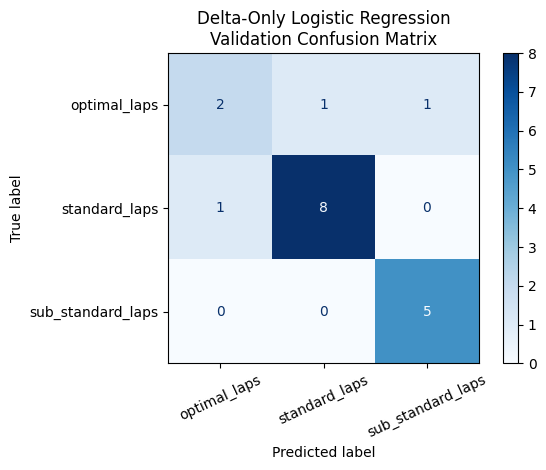

In [24]:
ConfusionMatrixDisplay.from_predictions(
    y_delta_validation,
    delta_validation_predictions,
    labels=list(range(num_classes)),
    display_labels=class_names,
    cmap="Blues",
    values_format="d",
)

plt.title(
    "Delta-Only Logistic Regression\n"
    "Validation Confusion Matrix"
)

plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

In [25]:
delta_validation_results = (
    delta_validation_df[[
        "global_lap_num",
        "session",
        "session_lap_num",
        "class_name",
        "class_index",
        "delta_1_seconds",
        "delta_2_seconds",
    ]]
    .copy()
)

delta_validation_results[
    "predicted_class_index"
] = delta_validation_predictions

delta_validation_results[
    "predicted_class_name"
] = [
    class_names[class_index]
    for class_index
    in delta_validation_predictions
]

delta_validation_results[
    "correct"
] = (
    delta_validation_results["class_index"]
    == delta_validation_results[
        "predicted_class_index"
    ]
)

display(delta_validation_results)

,global_lap_num,session,session_lap_num,class_name,class_index,delta_1_seconds,delta_2_seconds,predicted_class_index,predicted_class_name,correct
0,60,7,4,optimal_laps,0,1.023035,2.783274,0,optimal_laps,True
1,61,7,5,sub_standard_laps,2,1.694125,2.614024,2,sub_standard_laps,True
2,62,7,6,standard_laps,1,1.151784,3.022478,1,standard_laps,True
3,63,7,7,standard_laps,1,1.138358,2.626997,1,standard_laps,True
4,65,7,9,sub_standard_laps,2,2.213284,2.348233,2,sub_standard_laps,True
5,67,7,11,sub_standard_laps,2,1.325571,2.956957,2,sub_standard_laps,True
6,99,11,1,standard_laps,1,1.061455,2.881826,1,standard_laps,True
7,100,11,2,sub_standard_laps,2,1.763657,2.674258,2,sub_standard_laps,True
8,102,11,4,optimal_laps,0,1.530238,2.532409,2,sub_standard_laps,False
9,104,11,6,standard_laps,1,1.137733,2.716410,1,standard_laps,True


In [26]:
delta_model_class_order = (
    delta_model.named_steps[
        "classifier"
    ].classes_
)

print(
    "Logistic regression class order:",
    delta_model_class_order,
)

assert np.array_equal(
    delta_model_class_order,
    np.arange(num_classes),
), (
    "The probability columns do not match "
    "class indices 0, 1 and 2."
)

Logistic regression class order: [0 1 2]


In [27]:
delta_validation_probability_df = pd.DataFrame({
    "global_lap_num": (
        delta_validation_df[
            "global_lap_num"
        ].to_numpy()
    ),
    "true_class_index": y_delta_validation,
    "delta_predicted_class_index": (
        delta_validation_predictions
    ),
    "delta_probability_optimal": (
        delta_validation_probabilities[:, 0]
    ),
    "delta_probability_standard": (
        delta_validation_probabilities[:, 1]
    ),
    "delta_probability_sub_standard": (
        delta_validation_probabilities[:, 2]
    ),
})

display(
    delta_validation_probability_df.head()
)

,global_lap_num,true_class_index,delta_predicted_class_index,delta_probability_optimal,delta_probability_standard,delta_probability_sub_standard
0,60,0,0,0.489005,0.428463,0.082533
1,61,2,2,0.006812,0.225475,0.767714
2,62,1,1,0.139268,0.496220,0.364512
3,63,1,1,0.411254,0.483273,0.105473
4,65,2,2,0.000116,0.044943,0.954941


In [28]:
delta_validation_probability_path = (
    manifest_dir
    / "delta-validation-probabilities.csv"
)

delta_validation_probability_df.to_csv(
    delta_validation_probability_path,
    index=False,
)

print(
    "Saved validation probabilities to:",
    delta_validation_probability_path,
)

Saved validation probabilities to: C:\Users\admin\Desktop\Summer Projects\F1\F1-Optimized-Cornering-Project\Data\manifests\delta-validation-probabilities.csv


# Refined model direction

The final classifier could receive:

- 3 mean brake CNN probabilities
- 3 mean throttle CNN probabilities
- delta_1
- delta_2
- delta_gap
- delta_count
- delta_missing

Conceptually:
```
Brake images ── CNN ── brake probabilities ─┐
                                            │
Throttle images ─ CNN ─ throttle probs ─────┼─ Logistic regression ─ final class
                                            │
Brake/throttle deltas ─ telemetry features ─┘
```
Order of changes:

- Evaluate a delta-only logistic regression.
- Aggregate CNN predictions to lap level.
- Tune weighted probability fusion.
- Then train a logistic stacking model using out-of-fold CNN probabilities.

Only after those experiments should we consider changing ResNet18 or building a custom architecture.

The most promising first version is therefore not a larger neural network. It is a session-split lap-level ensemble consisting of ResNet18 plus logistic regression on delta_1 and delta_2.

## Doubts

- Should i train the break and throttle cnns separately?
- Is my understanding that the logistic regression model which will predict the final class, get the logits from my 2 cnns or for the two types of data, brake and throttle, and the brake and throttle deltas themselves and then it will make a dicision
- how would i go about training all these models?

## Some clarifications to remember:
608 total references
- 103 incident images
- 13 images from irregular 2+2 input laps
- 4 images from the lap exceeding 30 seconds

= 488 CNN images

### Session vs Lap Split 
Keep the current session split as your main evaluation because it is the more defensible generalisation test.

Later, we can also run a secondary lap-grouped experiment using the same model. Comparing them would be informative:

Lap-grouped performance
versus
Session-grouped performance

A large performance drop under session grouping would indicate that session-specific conditions matter substantially. That itself would be a valuable result rather than evidence that the session split was wrong.

vs 

So in order to maintain similar conditions, i made changes to the game settings so that the weather was always the same, same camera position, same setup, no ui, same track conditions, no damage and that includes tye deg., and had these setting in every session. Also the graphics settings were the same too.

The only difference across sessions was my skill which i think you can see from this plot from my analysis notebook.

**Should try lap split later**